# 1. Zero-Shot Prompting - Prompts Sin Ejemplos Previos

## Objetivos de Aprendizaje
- Comprender los principios del zero-shot prompting
- Diseñar prompts efectivos sin ejemplos previos
- Aplicar técnicas de instrucción clara y contexto
- Evaluar la efectividad de diferentes enfoques zero-shot

## ¿Qué es Zero-Shot Prompting?

Zero-shot prompting es la técnica donde pedimos al modelo realizar una tarea **sin proporcionar ejemplos específicos** de cómo debe hacerla. El modelo debe basarse únicamente en:
- Su entrenamiento previo
- Las instrucciones que le damos
- El contexto que proporcionamos

### Ventajas:
- **Simplicidad**: No requiere crear ejemplos
- **Flexibilidad**: Fácil de adaptar a nuevas tareas
- **Eficiencia**: Menos tokens utilizados
- **Generalización**: Funciona para tareas diversas

### Limitaciones:
- **Inconsistencia**: Resultados pueden variar más
- **Formato**: Menos control sobre la estructura de salida
- **Tareas complejas**: Puede requerir instrucciones muy detalladas
- **Dominio específico**: Menos efectivo en nichos especializados

In [4]:
%pip install -U langchain langchain-core langchain-openai langchain-community

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     --------- ------------------------------ 10.2/43.1 kB ? eta -:--:--
     --------- ------------------------------ 10.2/43.1 kB ? eta -:--:--
     --------------------------- ---------- 30.7/43.1 kB 262.6 kB/s eta 0:00:01
     --------------------------- ---------- 30.7/43.1 kB 262.6 kB/s eta 0:00:01
     ------------------------------------ - 41.0/43.1 kB 151.3 kB/s eta 0:00:01
     -------------------------------------- 43.1/43.1 kB 140.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/112.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/112.4 kB ? eta -:--:--
   ---------- ---------------------------- 30.7/112.4 kB 435.7 kB/s eta 0:00:01
   --------------------- ----

  You can safely remove it manually.


In [6]:
%pip install langchain-groq

   ---------------------------------------- 0.0/137.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/137.5 kB ? eta -:--:--
   -- ------------------------------------- 10.2/137.5 kB ? eta -:--:--
   -- ------------------------------------- 10.2/137.5 kB ? eta -:--:--
   -------- ------------------------------ 30.7/137.5 kB 217.9 kB/s eta 0:00:01
   ----------- --------------------------- 41.0/137.5 kB 196.9 kB/s eta 0:00:01
   ----------- --------------------------- 41.0/137.5 kB 196.9 kB/s eta 0:00:01
   ----------------- --------------------- 61.4/137.5 kB 217.9 kB/s eta 0:00:01
   ----------------------- --------------- 81.9/137.5 kB 229.0 kB/s eta 0:00:01
   -------------------------- ------------ 92.2/137.5 kB 227.6 kB/s eta 0:00:01
   ------------------------------------ - 133.1/137.5 kB 291.2 kB/s eta 0:00:01
   -------------------------------------- 137.5/137.5 kB 290.5 kB/s eta 0:00:00
  Attempting uninstall: groq
    Found existing installation: groq 0.11.0


## Get the api token 

1. Visit this URL: https://github.com/marketplace
2. Ask for the model OpenAI gpt-5. The url is: https://github.com/marketplace/models/azure-openai/gpt-5
3. Push the buttom: Use this model.
4. Push the buttom: "Create Personal Access Token".
5. Get your Personal Access Token.

In [ ]:
import os

os.environ["GITHUB_TOKEN"] = ""
os.environ["OPENAI_BASE_URL"] = ""
os.environ["GROQ_API_KEY"] =""


In [8]:
# Configuración inicial
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
import os
import time

# Configurar el modelo
llm = ChatOpenAI(
    base_url=os.getenv("OPENAI_BASE_URL"),
    api_key=os.getenv("GITHUB_TOKEN"),
    model="gpt-4o",
    temperature=0.7  # Balance entre creatividad y consistencia
)

print("✓ Modelo configurado para zero-shot prompting")

✓ Modelo configurado para zero-shot prompting


**Groq**

In [10]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
import json

# Initialize Groq LLM
llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.1-8b-instant",
    temperature=0.7
)

llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001ED9963BEC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001ED99D3EFF0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Anatomía de un Prompt Zero-Shot Efectivo

Un prompt zero-shot efectivo tiene estos componentes:

1. **Contexto/Rol**: Quién debe "ser" el modelo
2. **Tarea**: Qué debe hacer específicamente
3. **Formato**: Cómo debe estructurar la respuesta
4. **Restricciones**: Qué debe evitar o considerar
5. **Input**: Los datos específicos a procesar

In [4]:
# Ejemplo básico vs mejorado
def comparar_prompts_basico():
    texto = "El nuevo iPhone tiene una batería increíble y la cámara es fantástica, pero el precio es muy alto."
    
    # Prompt básico (menos efectivo)
    prompt_basico = f"Analiza este texto: {texto}"
    
    # Prompt mejorado (más efectivo)
    prompt_mejorado = f"""Eres un analista de sentimientos experto. 
    
Tarea: Analiza el sentimiento del siguiente texto sobre un producto.
    
Formato de respuesta:
- Sentimiento general: [Positivo/Negativo/Neutral]
- Aspectos positivos: [lista]
- Aspectos negativos: [lista]
- Puntuación de confianza: [0-10]
    
Texto a analizar: "{texto}"""
    
    print("=== COMPARACIÓN DE PROMPTS ===")
    
    # Probar prompt básico
    print("\n1. PROMPT BÁSICO:")
    print(f"Prompt: {prompt_basico}")
    try:
        response1 = llm.invoke([HumanMessage(content=prompt_basico)])
        print(f"Respuesta: {response1.content}")
    except Exception as e:
        print(f"Error: {e}")
    
    print("\n" + "-"*60)
    
    # Probar prompt mejorado
    print("\n2. PROMPT MEJORADO:")
    print(f"Prompt: {prompt_mejorado[:100]}...")
    try:
        response2 = llm.invoke([HumanMessage(content=prompt_mejorado)])
        print(f"Respuesta: {response2.content}")
    except Exception as e:
        print(f"Error: {e}")
    
    print("\n=== ANÁLISIS ===")
    print("• Prompt básico: Ambiguo, respuesta poco estructurada")
    print("• Prompt mejorado: Específico, respuesta estructurada y útil")

# Ejecutar comparación
comparar_prompts_basico()

=== COMPARACIÓN DE PROMPTS ===

1. PROMPT BÁSICO:
Prompt: Analiza este texto: El nuevo iPhone tiene una batería increíble y la cámara es fantástica, pero el precio es muy alto.
Error: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83293 seconds before retrying.', 'details': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83293 seconds before retrying.'}}

------------------------------------------------------------

2. PROMPT MEJORADO:
Prompt: Eres un analista de sentimientos experto. 
    
Tarea: Analiza el sentimiento del siguiente texto so...
Error: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83291 seconds before retrying.', 'details': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83291 seconds before retrying.'}}

=== ANÁLISIS ===
• Prompt básico:

## Técnicas de Zero-Shot por Tipo de Tarea

Diferentes tipos de tareas requieren enfoques específicos en zero-shot prompting.

In [4]:
# 1. CLASIFICACIÓN
def zero_shot_clasificacion():
    print("=== ZERO-SHOT PARA CLASIFICACIÓN ===")
    
    emails = [
        "Reunión de equipo mañana a las 10 AM en sala de conferencias",
        "¡Felicidades! Has ganado $1,000,000! Haz clic aquí ahora",
        "Recordatorio: Tu factura de internet vence en 3 días"
    ]
    
    # Prompt optimizado para clasificación
    clasificacion_prompt = """Eres un clasificador de emails empresariales.
    
Clasifica cada email en una de estas categorías:
- TRABAJO: Relacionado con tareas laborales
- SPAM: Contenido no solicitado o sospechoso
- PERSONAL: Asuntos personales o administrativos

Responde solo con el nombre de la categoría.

Email: "{}"
Categoría:"""
    
    for i, email in enumerate(emails, 1):
        prompt = clasificacion_prompt.format(email)
        try:
            response = llm.invoke([HumanMessage(content=prompt)])
            print(response)
            print(f"{i}. Email: {email[:50]}...")
            print(f"   Clasificación: {response.content.strip()}\n")
        except Exception as e:
            print(f"Error en email {i}: {e}")

# Ejecutar clasificación
zero_shot_clasificacion()

=== ZERO-SHOT PARA CLASIFICACIÓN ===
Error en email 1: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83416 seconds before retrying.', 'details': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83416 seconds before retrying.'}}
Error en email 2: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 10 per 60s exceeded for UserByModelByMinute. Please wait 51 seconds before retrying.', 'details': 'Rate limit of 10 per 60s exceeded for UserByModelByMinute. Please wait 51 seconds before retrying.'}}
Error en email 3: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83359 seconds before retrying.', 'details': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83359 seconds before retrying.'}}


In [5]:
# 2. GENERACIÓN DE CONTENIDO
def zero_shot_generacion():
    print("=== ZERO-SHOT PARA GENERACIÓN ===")
    
    # Prompt estructurado para generación
    generacion_prompt = """Eres un copywriter creativo especializado en redes sociales.
    
Tarea: Crear un post para LinkedIn sobre el tema dado.
    
Requisitos:
- Tono profesional pero accesible
- Máximo 150 palabras
- Incluir 1-2 hashtags relevantes
- Hacer una pregunta para fomentar engagement
    
Tema: "Importancia del aprendizaje continuo en tecnología"
    
Post para LinkedIn:"""
    
    try:
        response = llm.invoke([HumanMessage(content=generacion_prompt)])
        print("Post generado:")
        print("-" * 40)
        print(response.content)
        print("-" * 40)
        
        # Análisis del resultado
        words = len(response.content.split())
        hashtags = response.content.count('#')
        questions = response.content.count('?')
        
        print(f"\nAnálisis:")
        print(f"• Palabras: {words} (límite: 150)")
        print(f"• Hashtags: {hashtags}")
        print(f"• Preguntas: {questions}")
        print(f"• Cumple requisitos: {'✓' if words <= 150 and hashtags >= 1 and questions >= 1 else '✗'}")
        
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar generación
zero_shot_generacion()

=== ZERO-SHOT PARA GENERACIÓN ===
Error: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83357 seconds before retrying.', 'details': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83357 seconds before retrying.'}}


In [6]:
# 3. EXTRACCIÓN DE INFORMACIÓN
def zero_shot_extraccion():
    print("=== ZERO-SHOT PARA EXTRACCIÓN ===")
    
    # Texto de ejemplo
    texto_noticia = """Apple Inc. anunció hoy que su CEO Tim Cook se reunirá con inversores 
    el próximo 15 de marzo de 2024 en Cupertino, California. La reunión abordará los 
    resultados financieros del Q1 2024, donde la compañía reportó ingresos de $89.5 
    billones. Cook también discutirá la nueva estrategia de IA de Apple y el lanzamiento 
    del iPhone 16 programado para septiembre. Las acciones de Apple (AAPL) subieron 
    3.2% tras el anuncio."""
    
    # Prompt para extracción estructurada
    extraccion_prompt = f"""Eres un analista financiero experto en extraer datos clave.
    
Extrae la siguiente información del texto dado:
    
Formato de respuesta (JSON):
{{
  "empresa": "nombre de la empresa",
  "ceo": "nombre del CEO",
  "fecha_evento": "fecha del evento",
  "ubicacion": "ubicación del evento",
  "ingresos": "cifra de ingresos mencionada",
  "productos": ["lista de productos mencionados"],
  "cambio_acciones": "porcentaje de cambio en acciones"
}}
    
Texto: "{texto_noticia}"
    
JSON:"""
    
    try:
        response = llm.invoke([HumanMessage(content=extraccion_prompt)])
        print("Información extraída:")
        print(response.content)
        
        # Intentar parsear como JSON para validar formato
        import json
        try:
            data = json.loads(response.content)
            print("\n✓ Formato JSON válido")
            print(f"✓ Campos extraídos: {len(data)} elementos")
        except:
            print("\n✗ Formato JSON inválido - necesita refinamiento del prompt")
            
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar extracción
zero_shot_extraccion()

=== ZERO-SHOT PARA EXTRACCIÓN ===
Error: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83354 seconds before retrying.', 'details': 'Rate limit of 50 per 86400s exceeded for UserByModelByDay. Please wait 83354 seconds before retrying.'}}


**¿Como refinar el prompts para generar una respuesta estable como JSON**

In [7]:
# 3. EXTRACCIÓN DE INFORMACIÓN
def zero_shot_extraccion():
    print("=== ZERO-SHOT PARA EXTRACCIÓN ===")
    
    # Texto de ejemplo
    texto_noticia = """Apple Inc. anunció hoy que su CEO Tim Cook se reunirá con inversores 
    el próximo 15 de marzo de 2024 en Cupertino, California. La reunión abordará los 
    resultados financieros del Q1 2024, donde la compañía reportó ingresos de $89.5 
    billones. Cook también discutirá la nueva estrategia de IA de Apple y el lanzamiento 
    del iPhone 16 programado para septiembre. Las acciones de Apple (AAPL) subieron 
    3.2% tras el anuncio."""
    
    # Prompt para extracción estructurada
    extraccion_prompt = f"""Eres un analista financiero experto en extraer datos clave.
    
Extrae la siguiente información del texto dado:
    
Formato de respuesta (JSON):
{{
  "empresa": "nombre de la empresa",
  "ceo": "nombre del CEO",
  "fecha_evento": "fecha del evento",
  "ubicacion": "ubicación del evento",
  "ingresos": "cifra de ingresos mencionada",
  "productos": ["lista de productos mencionados"],
  "cambio_acciones": "porcentaje de cambio en acciones"
}}

El formato de respuesta debe ser un JSON, sin ninguna palabra, antes ni despues del JSON. Evita cualquier respuesta como esta:
```json
{{
  "empresa": "Apple Inc.",
  "ceo": "Tim Cook",
  "fecha_evento": "15 de marzo de 2024",
  "ubicacion": "Cupertino, California",
  "ingresos": "$89.5 billones",
  "productos": ["iPhone 16"],
  "cambio_acciones": "3.2%"
}}
```
Error: Esta la palabra json al inicio. Se consistente, y evita cualquier formato que no sea capaz de generar un JSON estable.

✗ Formato JSON inválido - necesita refinamiento del prompt
    
Texto: "{texto_noticia}"
    
JSON:"""
    
    try:
        response = llm.invoke([HumanMessage(content=extraccion_prompt)])
        print("Información extraída:")
        print(response.content)
        
        # Intentar parsear como JSON para validar formato
        import json
        try:
            data = json.loads(response.content)
            print("\n✓ Formato JSON válido")
            print(f"✓ Campos extraídos: {len(data)} elementos")
        except:
            print("\n✗ Formato JSON inválido - necesita refinamiento del prompt")
            
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar extracción
zero_shot_extraccion()

=== ZERO-SHOT PARA EXTRACCIÓN ===
Error: Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 10 per 60s exceeded for UserByModelByMinute. Please wait 51 seconds before retrying.', 'details': 'Rate limit of 10 per 60s exceeded for UserByModelByMinute. Please wait 51 seconds before retrying.'}}


## Optimización de Prompts Zero-Shot

Técnicas para mejorar la efectividad de prompts zero-shot.

In [ ]:
# Técnica 1: Prompts con Roles Específicos
def roles_especificos():
    print("=== OPTIMIZACIÓN: ROLES ESPECÍFICOS ===")
    
    pregunta = "¿Cómo puedo mejorar el rendimiento de mi aplicación web?"
    
    roles = {
        "Genérico": "Responde la siguiente pregunta:",
        "Desarrollador Senior": "Eres un desarrollador senior con 10 años de experiencia en optimización web. Responde como un experto:",
        "Consultor de Performance": "Eres un consultor especializado en performance web que ha optimizado cientos de aplicaciones. Proporciona una respuesta detallada y técnica:",
        "CTO": "Eres un CTO de una startup tecnológica. Responde con una perspectiva estratégica y técnica balanceada:"
    }
    
    for rol, contexto in roles.items():
        prompt = f"{contexto}\n\n{pregunta}"
        
        print(f"\n{rol.upper()}:")
        print("-" * 30)
        
        try:
            response = llm.invoke([HumanMessage(content=prompt)])
            # Mostrar solo las primeras líneas para comparación
            preview = response.content[:200] + "..." if len(response.content) > 200 else response.content
            print(preview)
        except Exception as e:
            print(f"Error: {e}")
    
    print("\n=== OBSERVACIONES ===")
    print("• Roles específicos generan respuestas más enfocadas")
    print("• La experticia del rol influye en la profundidad técnica")
    print("• El contexto profesional afecta el tipo de soluciones propuestas")

# Ejecutar ejemplo de roles
roles_especificos()

=== OPTIMIZACIÓN: ROLES ESPECÍFICOS ===

GENÉRICO:
------------------------------


In [ ]:
# Técnica 2: Instrucciones Graduales
def instrucciones_graduales():
    print("=== OPTIMIZACIÓN: INSTRUCCIONES GRADUALES ===")
    
    # Problema complejo para demostrar
    problema = "Necesito crear una estrategia de marketing digital para lanzar una nueva app de fitness"
    
    # Prompt con instrucciones graduales
    prompt_gradual = f"""Eres un estratega de marketing digital senior.
    
Problema: {problema}
    
Desarrolla una estrategia siguiendo este proceso paso a paso:
    
PASO 1: Análisis inicial
- Identifica el público objetivo
- Define 3 puntos de valor únicos de la app
    
PASO 2: Canales de marketing
- Selecciona 4-5 canales digitales más efectivos
- Justifica cada selección
    
PASO 3: Estrategia de contenido
- Define tipos de contenido para cada canal
- Sugiere frecuencia de publicación
    
PASO 4: Métricas y KPIs
- Define 5 métricas clave para medir éxito
- Sugiere herramientas de medición
    
Desarrolla cada paso con detalle:"""
    
    try:
        response = llm.invoke([HumanMessage(content=prompt_gradual)])
        print("ESTRATEGIA DESARROLLADA:")
        print("=" * 50)
        print(response.content)
        
        # Análisis de estructura
        pasos_detectados = response.content.count("PASO")
        secciones = ["análisis", "canales", "contenido", "métricas"]
        secciones_encontradas = sum(1 for seccion in secciones if seccion.lower() in response.content.lower())
        
        print("\n=== ANÁLISIS DE ESTRUCTURA ===")
        print(f"• Pasos identificados: {pasos_detectados}/4")
        print(f"• Secciones cubiertas: {secciones_encontradas}/4")
        print(f"• Estructura seguida: {'✓' if pasos_detectados >= 3 else '✗'}")
        
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar instrucciones graduales
instrucciones_graduales()

=== OPTIMIZACIÓN: INSTRUCCIONES GRADUALES ===
ESTRATEGIA DESARROLLADA:
¡Claro! Desarrollaré una estrategia de marketing digital para el lanzamiento de tu nueva app de fitness paso a paso.

---

## **PASO 1: Análisis inicial**

### **Identifica el público objetivo**
1. **Demografía:**
   - Edad: 20-40 años.
   - Género: Hombres y mujeres.
   - Ubicación: Principalmente zonas urbanas con acceso a smartphones y buena conexión a internet.
   - Nivel socioeconómico: Medio y medio-alto.

2. **Psicografía:**
   - Personas interesadas en el fitness, la salud y el bienestar.
   - Usuarios que buscan soluciones accesibles para entrenar en casa o en el gimnasio.
   - Profesionales ocupados que necesitan flexibilidad para mantenerse en forma.

3. **Comportamientos:**
   - Usuarios de apps de fitness, dispositivos wearables o rastreadores de actividad.
   - Compradores de suplementos, ropa deportiva o equipos de ejercicio.
   - Seguidores de influencers de fitness en redes sociales.

---

### **Def

## Casos de Uso Avanzados

Aplicaciones más sofisticadas de zero-shot prompting.

In [ ]:
# Caso de uso: Análisis de código
def analisis_codigo_zero_shot():
    print("=== CASO DE USO: ANÁLISIS DE CÓDIGO ===")
    
    codigo_ejemplo = '''def process_user_data(users):
    result = []
    for user in users:
        if user["age"] > 18:
            result.append({
                "name": user["name"].upper(),
                "email": user["email"],
                "status": "adult"
            })
    return result'''
    
    prompt_analisis = f"""Eres un senior code reviewer con experiencia en Python.
    
Analiza el siguiente código y proporciona:
    
1. FUNCIONALIDAD:
   - ¿Qué hace este código?
   - ¿Cuál es su propósito?
    
2. PROBLEMAS POTENCIALES:
   - Errores de lógica
   - Vulnerabilidades de seguridad
   - Problemas de rendimiento
    
3. MEJORAS SUGERIDAS:
   - Optimizaciones de código
   - Mejores prácticas
   - Manejo de errores
    
4. PUNTUACIÓN DE CALIDAD: [1-10]
    
Código a analizar:
```python
{codigo_ejemplo}
```
    
Análisis:"""
    
    try:
        response = llm.invoke([HumanMessage(content=prompt_analisis)])
        print("ANÁLISIS DE CÓDIGO:")
        print("=" * 50)
        print(response.content)
        
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar análisis de código
analisis_codigo_zero_shot()

=== CASO DE USO: ANÁLISIS DE CÓDIGO ===
ANÁLISIS DE CÓDIGO:
### Análisis del código

#### 1. FUNCIONALIDAD:
   - **¿Qué hace este código?**
     Este código toma una lista de diccionarios (`users`), donde cada diccionario representa un usuario con al menos las claves `"age"`, `"name"` y `"email"`. Recorre cada usuario y filtra aquellos cuya edad (`age`) sea mayor a 18 años. Para estos usuarios, crea un nuevo diccionario con:
       - El nombre del usuario (`name`) convertido a mayúsculas.
       - El correo electrónico (`email`).
       - Un estado (`status`) que siempre se establece como `"adult"`.
     Finalmente, devuelve una lista (`result`) con los diccionarios procesados.

   - **¿Cuál es su propósito?**
     El propósito del código parece ser procesar y filtrar información de usuarios, específicamente identificar a los mayores de edad (18 años o más) y formatear sus datos para algún tipo de consumo (como reportes, almacenamiento o visualización).

---

#### 2. PROBLEMAS POTENCIA

In [ ]:
# Caso de uso: Generación de tests
def generacion_tests_zero_shot():
    print("=== CASO DE USO: GENERACIÓN DE TESTS ===")
    
    funcion_a_testear = '''def calculate_discount(price, discount_percent, user_type):
    """Calculate final price after discount.
    
    Args:
        price (float): Original price
        discount_percent (float): Discount percentage (0-100)
        user_type (str): 'premium' or 'regular'
        
    Returns:
        float: Final price after discount
    """
    if user_type == 'premium':
        discount_percent += 5  # Extra 5% for premium users
    
    discount_amount = price * (discount_percent / 100)
    return price - discount_amount'''
    
    prompt_tests = f"""Eres un QA engineer experto en testing de Python.
    
Genera tests unitarios completos para la siguiente función usando pytest.
    
Incluye tests para:
1. Casos normales (diferentes tipos de usuario y descuentos)
2. Casos edge (descuento 0%, 100%, valores negativos)
3. Casos de error (tipos incorrectos, valores inválidos)
4. Tests parametrizados cuando sea apropiado
    
Función a testear:
```python
{funcion_a_testear}
```
    
Genera código de test completo y ejecutable:"""
    
    try:
        response = llm.invoke([HumanMessage(content=prompt_tests)])
        print("TESTS GENERADOS:")
        print("=" * 50)
        print(response.content)
        
        # Análisis básico de los tests generados
        test_methods = response.content.count("def test_")
        assertions = response.content.count("assert")
        parametrize = response.content.count("@pytest.mark.parametrize")
        
        print("\n=== ANÁLISIS DE TESTS ===")
        print(f"• Métodos de test: {test_methods}")
        print(f"• Assertions: {assertions}")
        print(f"• Tests parametrizados: {parametrize}")
        print(f"• Cobertura estimada: {'Alta' if test_methods >= 5 else 'Media' if test_methods >= 3 else 'Baja'}")
        
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar generación de tests
generacion_tests_zero_shot()

=== CASO DE USO: GENERACIÓN DE TESTS ===
TESTS GENERADOS:
Aquí tienes un conjunto completo de tests unitarios para la función `calculate_discount` usando `pytest`. Estos tests cubren los casos normales, edge cases y casos de error, tal como pediste:

### Código de prueba:

```python
import pytest
from your_module import calculate_discount  # Cambia 'your_module' por el nombre de tu archivo Python

# Test 1: Casos normales (diferentes tipos de usuario y descuentos)
@pytest.mark.parametrize("price, discount_percent, user_type, expected", [
    (100.0, 10.0, 'regular', 90.0),  # Regular user, 10% discount
    (200.0, 20.0, 'premium', 150.0),  # Premium user, 20% discount + 5% extra
    (50.0, 30.0, 'regular', 35.0),  # Regular user, 30% discount
    (75.0, 15.0, 'premium', 60.0),  # Premium user, 15% discount + 5% extra
])
def test_calculate_discount_normal_cases(price, discount_percent, user_type, expected):
    assert calculate_discount(price, discount_percent, user_type) == pytest.appr

## Mejores Prácticas y Limitaciones

### ✅ Cuándo Usar Zero-Shot:
- Tareas comunes y bien definidas
- Cuando no tienes ejemplos disponibles
- Para prototipado rápido
- Tareas que requieren creatividad

### ❌ Cuándo NO Usar Zero-Shot:
- Formatos de salida muy específicos
- Tareas de dominio muy especializado
- Cuando la consistencia es crítica
- Tareas complejas que requieren patrones específicos

### 🎯 Mejores Prácticas:
1. **Sé específico**: Detalla exactamente qué quieres
2. **Define el formato**: Especifica cómo debe verse la salida
3. **Establece restricciones**: Qué debe evitar o considerar
4. **Usa roles**: Define quién debe "ser" el modelo
5. **Itera y refina**: Mejora basándote en resultados

In [ ]:
# Ejercicio final: Diseña tu propio prompt zero-shot
def ejercicio_personalizado():
    print("=== EJERCICIO PERSONAL ===")
    print("\nDiseña un prompt zero-shot para esta tarea:")
    print("'Crear una descripción de trabajo atractiva para un puesto de desarrollador Python junior'")
    print("\nEstructura sugerida:")
    print("1. Rol/Contexto del modelo")
    print("2. Tarea específica")
    print("3. Requisitos del formato")
    print("4. Restricciones importantes")
    print("\nTu prompt aquí:")
    
    # Espacio para que el estudiante diseñe su prompt
    prompt_estudiante = """# COLOCA TU PROMPT AQUÍ
    
# Ejemplo de estructura:
# Eres un [ROL]...
# Tarea: [TAREA ESPECÍFICA]...
# Formato: [ESTRUCTURA DE SALIDA]...
# Restricciones: [LIMITACIONES]...
"""
    
    print(prompt_estudiante)
    
    # Prompt de ejemplo bien estructurado
    ejemplo_prompt = """Eres un HR Business Partner senior especializado en tecnología con 8 años de experiencia reclutando desarrolladores.
    
Tarea: Redacta una descripción de trabajo atractiva y realista para un puesto de Desarrollador Python Junior.
    
Formato requerido:
- Título del puesto
- Resumen ejecutivo (2-3 líneas)
- Responsabilidades principales (4-5 puntos)
- Requisitos técnicos (separar esenciales de deseables)
- Beneficios y cultura de empresa
- Llamada a la acción
    
Restricciones:
- Máximo 400 palabras
- Lenguaje inclusivo y accesible
- Enfócate en crecimiento profesional
- Evita jerga técnica excesiva
- Sé honesto sobre el nivel junior
    
Descripción de trabajo:"""
    
    print("\n=== EJEMPLO DE PROMPT BIEN ESTRUCTURADO ===")
    print(ejemplo_prompt)
    
    # Opcional: probar el prompt ejemplo
    print("\n¿Quieres ver el resultado del prompt ejemplo? (y/n)")
    # En un entorno real, aquí habría input del usuario
    
ejercicio_personalizado()

=== EJERCICIO PERSONAL ===

Diseña un prompt zero-shot para esta tarea:
'Crear una descripción de trabajo atractiva para un puesto de desarrollador Python junior'

Estructura sugerida:
1. Rol/Contexto del modelo
2. Tarea específica
3. Requisitos del formato
4. Restricciones importantes

Tu prompt aquí:
# COLOCA TU PROMPT AQUÍ
    
# Ejemplo de estructura:
# Eres un [ROL]...
# Tarea: [TAREA ESPECÍFICA]...
# Formato: [ESTRUCTURA DE SALIDA]...
# Restricciones: [LIMITACIONES]...


=== EJEMPLO DE PROMPT BIEN ESTRUCTURADO ===
Eres un HR Business Partner senior especializado en tecnología con 8 años de experiencia reclutando desarrolladores.
    
Tarea: Redacta una descripción de trabajo atractiva y realista para un puesto de Desarrollador Python Junior.
    
Formato requerido:
- Título del puesto
- Resumen ejecutivo (2-3 líneas)
- Responsabilidades principales (4-5 puntos)
- Requisitos técnicos (separar esenciales de deseables)
- Beneficios y cultura de empresa
- Llamada a la acción
    
Res

## Conceptos Clave Aprendidos

1. **Zero-shot prompting** es efectivo para tareas comunes sin necesidad de ejemplos
2. **Estructura clara** del prompt mejora significativamente los resultados
3. **Roles específicos** generan respuestas más enfocadas y expertas
4. **Instrucciones graduales** ayudan con tareas complejas
5. **Formato definido** asegura salidas consistentes y útiles

## Próximos Pasos

En el siguiente notebook exploraremos **Few-Shot Prompting**, donde aprenderemos a usar ejemplos específicos para guiar el comportamiento del modelo y lograr mayor consistencia en tareas especializadas.

### Para Practicar:
1. Construye un algoritmo para medir la consistencia de un prompt con estructura (formato JSON la respuesta) y un prompt sin estructura. Mide el rendimiento en razon al formato esperado.



**Prompt Con Estructura**

In [11]:
import json

def llm_with_prompt(prompt_system, feedback):

    try:
        response = llm.invoke([HumanMessage(content=prompt_system)])
        print(response.content)
        result = json.loads(response.content)
  
        return {
           "sentimientos":result["sentimientos"],  
           "nota":result["nota"]
        }       # 8

    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        print(f"Raw response: {response.content}")
        return {
           "sentimientos":False,  
           "nota":False
        }  
    except Exception as e:
        print(e)
        return {
           "sentimientos":False,  
           "nota":False
        } 



In [20]:


import random
import pandas as pd 

feedbacks = [
    # Positivos
    "La experiencia fue excelente, el servicio superó mis expectativas.",
    "Muy satisfecho con la atención recibida, volvería sin dudarlo.",
    "El producto llegó rápido y en perfectas condiciones, gracias.",
    "Increíble servicio al cliente, resolvieron mi problema de inmediato.",
    "Todo perfecto, muy buena calidad y atención.",
    
    # Negativos
    "Pésima experiencia, el producto llegó dañado y nadie me ayudó.",
    "El servicio fue terrible, esperé horas sin respuesta.",
    "Muy decepcionado, no cumplieron con lo prometido.",
    "La atención fue grosera y el problema nunca se resolvió.",
    "No recomendaría este servicio para nada, muy mala experiencia.",
    
    # Neutros
    "El servicio fue normal, nada especial pero tampoco malo.",
    "Cumplió con lo básico, aunque podría mejorar.",
    "La experiencia fue estándar, ni buena ni mala.",
    "El producto está bien, aunque el envío tardó más de lo esperado.",
    "Todo correcto, sin inconvenientes pero tampoco destacable.",
]

structured_responses = []
unstructured_responses = []

for i in range(5):

    feedback = random.choice(feedbacks)
    ### 
    structured_prompt_system = f"""
        ROLE:
        Tu eres un experto en experiencia de clientes. 

        MISION:
        Tu rol es calificar y extraer el sentimientos del mensaje de los clientes. 

        INSTRUCCION:
        Tu recibir el feedback de los clientes y debes obtener lo siguiente:
        1- Sentimiento del mensaje (POSITIVO, NEGATIVO O NEUTRO)
        2- Escala de 1 a 10, donde 1 es negativo y 10 es positivo. Debe ser solo numeros.

        OUTPUT:
        Tu resultados debe estar en el siguiente formato:
        {{"sentimientos": "NEGATIVO", "nota": 1}}
        Tu resultados siempre debe ser un JSON. No pongas ninguna palabra antes, ni despues, solo el JSON. No pongas un formato asi:
        ""json{{"sentimientos": POSITIVO/NEUTRO/NEGATIVO, "nota": 1-10}}""
        NUNCA pongas la palabra JSON. 
        Responde ÚNICAMENTE con JSON válido. Los valores de texto DEBEN estar entre comillas dobles.
        Ejemplo: {{"sentimientos": "NEGATIVO", "nota": 1}}

    Feedbackuser: {feedback}
    :"""

    structured_response = llm_with_prompt(structured_prompt_system, feedback)
    structured_responses.append({
        'type': "structured",
        'sentimientos': structured_response['sentimientos'],
        'nota': structured_response['nota'],
    })


    ### 
    unstructured_prompt_system = f"""
        ROLE:
        Tu eres un experto en experiencia de clientes. 
        Tu rol es calificar y extraer el sentimientos del mensaje de los clientes. 
        Debe darme el sentimiento, que puede ser NEGATIVO, POSITIVO O NEUTRO y una nota de 1 a 10. 
        La respuesta debe estar en formato JSON, como sentimientos y nota como su schema.
        Feedbackuser: {feedback}
    :"""

    unstructured_response = llm_with_prompt(unstructured_prompt_system, feedback)
    unstructured_responses.append({
        'type': "unstructured",
        'sentimientos': unstructured_response['sentimientos'],
        'nota': unstructured_response['nota'],
    })


df1 = pd.DataFrame(structured_responses)
df2 = pd.DataFrame(unstructured_responses)

df1['status'] = df1.apply(
    lambda row: 0 if row['sentimientos'] is False or row['nota'] is False else 1, 
    axis=1
)

df2['status'] = df2.apply(
    lambda row: 0 if row['sentimientos'] is False or row['nota'] is False else 1, 
    axis=1
)

total = pd.concat([df1, df2], axis=1)

total


{"sentimientos": "POSITIVO", "nota": 10}
**Sentimiento y nota del mensaje del cliente**

```json
{
  "sentimientos": "POSITIVO",
  "nota": 10
}
```

En este caso, el sentimiento del mensaje del cliente es POSITIVO porque utiliza palabras como "perfecto", "muy buena calidad" y "atención", lo que indica que está satisfecho con la experiencia. La nota de 10 indica que el cliente está extremadamente satisfecho.
Error parsing JSON: Expecting value: line 1 column 1 (char 0)
Raw response: **Sentimiento y nota del mensaje del cliente**

```json
{
  "sentimientos": "POSITIVO",
  "nota": 10
}
```

En este caso, el sentimiento del mensaje del cliente es POSITIVO porque utiliza palabras como "perfecto", "muy buena calidad" y "atención", lo que indica que está satisfecho con la experiencia. La nota de 10 indica que el cliente está extremadamente satisfecho.
{"sentimientos": "NEGATIVO", "nota": 4}
```json
{
  "sentimiento": "NEUTRO",
  "nota": 6
}
```

La nota de 6 indica que la experiencia del clie

,type,sentimientos,nota,status,type,sentimientos,nota,status
0,structured,POSITIVO,10,1,unstructured,False,False,0
1,structured,NEGATIVO,4,1,unstructured,False,False,0
2,structured,NEUTRO,5,1,unstructured,False,False,0
3,structured,NEGATIVO,1,1,unstructured,False,False,0
4,structured,NEUTRO,5,1,unstructured,False,False,0


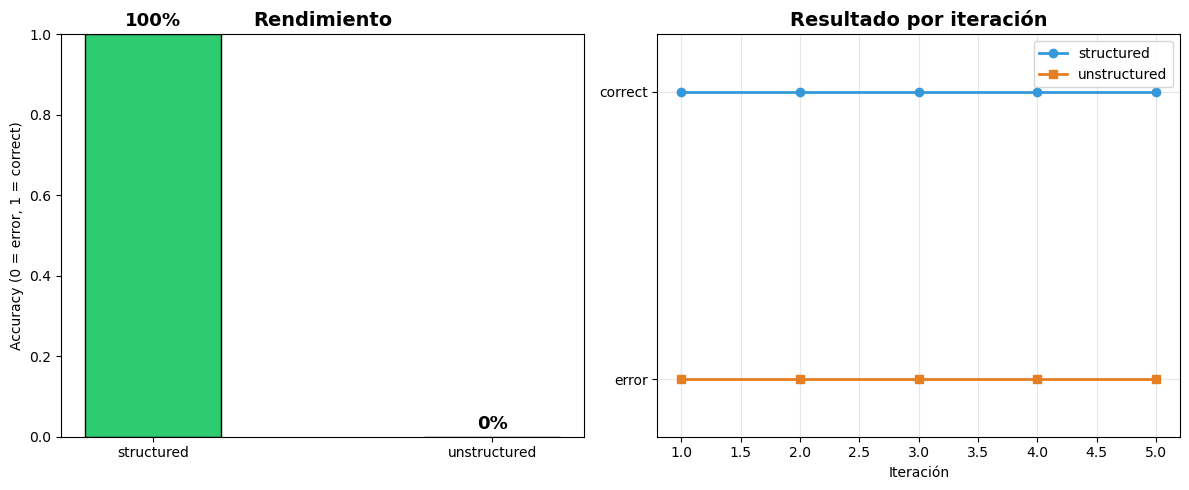

Accuracy structured:   100% (5/5 correctos)
Accuracy unstructured: 0% (0/5 correctos)


In [23]:
import matplotlib.pyplot as plt

accuracy_df = pd.DataFrame({
    'structured': [df1['status'].mean()],
    'unstructured': [df2['status'].mean()]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tipos = ['structured', 'unstructured']
accuracies = [df1['status'].mean(), df2['status'].mean()]
colors = ['#2ecc71' if a >= 0.5 else '#e74c3c' for a in accuracies]

axes[0].bar(tipos, accuracies, color=colors, edgecolor='black', width=0.4)
axes[0].set_ylim(0, 1)
axes[0].set_title('Rendimiento', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (0 = error, 1 = correct)')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=13, fontweight='bold')

axes[1].plot(range(1, len(df1)+1), df1['status'], marker='o', label='structured', color='#3498db', linewidth=2)
axes[1].plot(range(1, len(df2)+1), df2['status'], marker='s', label='unstructured', color='#e67e22', linewidth=2)
axes[1].set_ylim(-0.2, 1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['error', 'correct'])
axes[1].set_xlabel('Iteración')
axes[1].set_title('Resultado por iteración', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Accuracy structured:   {df1['status'].mean():.0%} ({df1['status'].sum()}/{len(df1)} correctos)")
print(f"Accuracy unstructured: {df2['status'].mean():.0%} ({df2['status'].sum()}/{len(df2)} correctos)")
